In [2]:
!pip install -U transformers accelerate bitsandbytes
!pip install -U langchain langchain-community langchain-huggingface
!pip install -U sentence-transformers sentencepiece

In [3]:
import pandas as pd

#create data dict
data = {

      "question": [
        "What was the economic growth rate of Albania in 2003?",
        "What was the annual inflation rate by the end of November 2003?",
        "How did the monetary policy of the Bank of Albania affect interest rates in 2003?",
        "What factors contributed to the economy’s growth in 2003?",
        "How did the Albanian government manage its budget deficit in 2003?",
        "How much did Albania’s GDP grow in 2003?",
        "What was the inflation rate of Albania in December 2003?",
        "What was the REPO rate reduction in Albania as of May 2004?",
        "How did the appreciation of the domestic currency affect the economy in 2003?",
        "What significant change happened to the banking sector in 2003?",
        "What was one of the main risks identified for the Albanian banking system in 2017?",
        "What is the GDP growth forecast for Albania in 2017?",
        "What issue concerning inequality was raised in the Transition Report 2016-2017?",
        "How did the banking system's liquidity perform in 2017?",
        "What role does financial education play according to the Bank of Albania?",
        "What is the motto of Global Money Week?",
        "How many activities were organized during Global Money Week in 2017 in Albania?",
        "How many students participated in the Global Money Week events in 2017?",
        "What is the purpose of the financial education initiatives organized by the Bank of Albania?",
        "What collaborative effort supports financial education in Albania?",
        "What was Albania's economic growth rate in 2016?",
        "What was the inflation rate in Albania at the end of 2016?",
        "How did Albania’s public debt change in 2016?",
        "How did the accommodative monetary policy of the Bank of Albania impact lending in 2016?",
        "What two main obstacles did the Bank of Albania identify in the monetary policy pass-through mechanism?",
        "What was the Albanian economy’s growth rate in the second quarter of 2017?",
        "What factors contributed to Albania's economic recovery in 2017?",
        "What was the effect of Albania's monetary policy on the economy?",
        "How did non-performing loans in Albania change from 2014 to 2017?",
        "What role does the banking sector play in Albania's economic recovery?",
        "What financial indicator showed improvement in 2017 for Albanian enterprises?",
        "What is a significant challenge for the Albanian financial system according to the speech?",
        "What percentage of the Albanian population had a financial account in 2014?",
        "How did Albania compare to OECD countries in terms of financial inclusion in 2014?",
        "What is the role of the Albanian banking sector in addressing informality in the economy?",
        "What is the impact of remittances on the Albanian economy?",
        "What percentage of remittance transfers to Albania occurs through formal channels?",
        "Why do some Albanians abroad avoid using banking channels for remittances?",
        "What were the estimated costs of remittance transfers to Albania in 2016?",
        "How do remittances contribute to the balance of payments in Albania?",
        "How does the Bank of Albania plan to improve the efficiency of remittance flows?",
        "What is the Greenback project, and how does it relate to Albania?",
        "What is the primary use of remittances by Albanian households?",
        "What impact do remittances have on poverty in Albania?",
        "What action did the Bank of Albania commit to in relation to remittances?",
        "What was the purpose of the agreement between the Bank of Albania and SECO?",
        "How many activities were realized under the first phase of the SECO cooperation from 2013–2018?",
        "How did the Bank of Albania benefit from the cooperation with SECO?",
        "What role did SECO play in Albania’s monetary policy?",
        "How many staff members participated in SECO-related workshops during the first phase of the program?",
        "What academic opportunities did the SECO program offer to Bank of Albania employees?",
        "What impact did the SECO-funded forecasting models have on Albania's exchange rate management?",
        "How has SECO-supported research contributed to financial stability in Albania?",
        "What is the expected outcome of the second phase of SECO cooperation?",
        "What are the key priorities of the Bank of Albania under the SECO cooperation?",
        "What was the economic contraction of Albania during the second quarter of 2020 due to COVID-19?",
        "How many jobs were lost in Albania by the end of 2020?",
        "What was the inflation rate in Albania during the third quarter of 2020?",
        "How did the Bank of Albania respond to the COVID-19 economic crisis?",
        "How did the Albanian banking sector perform during the COVID-19 pandemic?",
        "What are the future challenges for Albania’s economy post-pandemic?",
        "What is the expected recovery period for the Albanian economy after COVID-19?",
        "What research areas dominated the 14th SEE Economic Research Workshop in 2020?",
        "What financial measures did the Bank of Albania take to stabilize the economy?",
        "What new topics are expected to gain attention in future workshops?",
        "How did the Bank of Albania respond to the COVID-19 pandemic in terms of monetary policy?",
        "What fiscal measures did the Albanian government implement during the COVID-19 pandemic?",
        "What regulatory measures did the Bank of Albania take to support borrowers during the pandemic?",
        "How did the Bank of Albania maintain financial stability during the COVID-19 crisis?",
        "What is the long-term policy outlook according to the Bank of Albania following the COVID-19 pandemic?",
        "What global economic challenge is highlighted as a long-term consequence of the pandemic?",
        "How has the COVID-19 pandemic accelerated changes in the financial sector?",
        "What role does fiscal policy play in managing the economic recovery post-COVID?",
        "What long-term challenge is associated with work-life balance due to the pandemic?",
        "How does the pandemic affect climate change discussions, according to the Bank of Albania?",
        "How did the COVID-19 pandemic affect GDP in the Western Balkans in 2020?",
        "What unconventional measures did central banks in the Western Balkans deploy during the pandemic?",
        "What fiscal measures did the Albanian government take to support businesses during the pandemic?",
        "How did the Bank of Albania support viable businesses facing temporary difficulties during the pandemic?",
        "What immediate regulatory action did the Bank of Albania take to strengthen the banking sector during the pandemic?",
        "How did the Rapid Financing Instrument (RFI) assist Albania during the pandemic?",
        "What impact did the Bank of Albania’s policies have on the banking sector during the pandemic?",
        "What key challenge is highlighted by the Bank of Albania regarding the post-pandemic recovery?",
        "What does the Bank of Albania emphasize as critical for long-term economic growth?",
        "What role does international cooperation play according to the Bank of Albania during the pandemic?",
        "What was the main cause of the financial crisis in Indonesia in 1997?",
        "How did Indonesia respond to the currency crisis in 1998?",
        "What was Indonesia's GDP growth rate in 1998?",
        "How did inflation in Indonesia behave during the worst point of the crisis?",
        "What was the role of Bank Indonesia in stabilizing inflation?",
        "How did Bank Indonesia address the trade finance arrears in 1998?",
        "What was the purpose of Indonesia’s Debt Restructuring Agency (INDRA)?",
        "How did the 1998 Jakarta Initiative contribute to economic recovery?",
        "How did the 1999 bank recapitalization program work in Indonesia?",
        "What was the expected role of the government in the Indonesian banking sector after the crisis?",
        "What was the main theme of the keynote speech by Agus D.W. Martowardojo at the International Seminar in Surabaya, 2016?",
        "What are the three sectors mentioned as pillars for fostering Islamic economic development?",
        "What percentage of global Islamic commercial finance is dominated by the Islamic banking sector?",
        "How did Islamic banking growth perform from 2008 to 2011 compared to 2011 to 2014?",
        "What was the global trend in Sukuk issuances between 2012 and 2015?",
        "How did the Islamic banking sector in Indonesia perform by July 2016?",
        "What potential does the Islamic social finance sector (zakat, awqaf) offer according to the speech?",
        "What is the role of zakat in poverty alleviation according to the keynote speech?",
        "What are the future goals of Bank Indonesia regarding Islamic finance as mentioned in the speech?",
        "What was the purpose of establishing the Zakat Core Principles?",
        "What was the theme of Bank Indonesia's 2020 annual meeting?",
        "How did the COVID-19 pandemic impact Indonesia’s economy in 2020?",
        "What fiscal stimulus did the Indonesian government provide during the COVID-19 pandemic?",
        "What was the projection for global economic growth in 2021 according to Bank Indonesia?",
        "What role did Bank Indonesia play in stabilizing the rupiah during the COVID-19 crisis?",
        "What was the impact of quantitative easing in emerging market economies during the pandemic?",
        "What were the key strategies for Indonesia’s economic recovery in 2021?",
        "How did Bank Indonesia support Micro, Small, and Medium Enterprises (MSMEs) during the pandemic?",
        "How did the COVID-19 pandemic affect Indonesia’s trade performance in 2020?",
        "What was the expected inflation rate in Indonesia for 2020?",
        "What was one of the major changes in the global financial system following the breakdown of the Bretton Woods system?",
        "What has been a primary objective of monetary policy in recent years?",
        "What are the two key functions of central banks discussed in this speech?",
        "How has financial liberalization affected banking sectors globally?",
        "What approach has evolved in central bank supervision concerning systemic stability?",
        "What has been the trend in the use of monetary policy instruments?",
        "How have technological advances impacted financial markets?",
        "What was one consequence of financial liberalization mentioned in the speech?",
        "What is one challenge central banks face due to more complete financial markets?",
        "What has been the impact of floating exchange rates on macroeconomic policies?",
        "What is one major responsibility of central banks discussed in the speech?",
        "What is a consequence of advances in information technology in financial markets?",
        "How did liberalization and innovation affect financial systems?",
        "What lesson can be drawn from recent financial crises according to the speaker?",
        "What was one of the macroeconomic challenges faced by East Asian countries during the financial crisis?",
        "What was the role of prudential regulation in financial crises?",
        "How does financial liberalization relate to capital market integration?",
        "What is the importance of exchange rate management during financial crises?",
        "What was one recommendation for handling banking system weaknesses?",
        "What was the speaker’s stance on official financing packages for resolving crises?",
        "What is the role of financial inclusion in economic development?",
        "What technological innovation is driving financial inclusion in remote areas?",
        "How has financial inclusion impacted global unbanked populations?",
        "What is the relationship between financial inclusion and financial stability?",
        "How does mobile money benefit local economies?",
        "What is a challenge faced by financial institutions in serving financially excluded populations?",
        "What impact does de-risking have on financial inclusion?",
        "Why is financial education important for new financial services users?",
        "What data-related challenge is highlighted in the speech?",
        "How can financial innovations positively impact the world’s financially excluded populations?",
        "What was the purpose of the SNB's COVID-19 refinancing facility (CRF)?",
        "How does the SARON differ from the previous Libor rate in the Swiss franc money market?",
        "Why are Swiss franc interest rates generally lower than those of other currencies?",
        "What role does the Swiss Money Market Value Chain play in Switzerland's financial infrastructure?",
        "What adjustments were made to the exemption thresholds in response to the coronavirus crisis?"
    ],

    "ground_truth": [
        "The economic growth rate was forecasted to be about 6 percent.",
        "The annual inflation rate by the end of November 2003 was 3.4 percent.",
        "The Bank of Albania reduced interest rates three times, lowering the Repos rate by 1.5 percentage points.",
        "Factors included stability in agricultural production, positive performance in services, industry, transport, increased trade volume, and remittances.",
        "The budget deficit was financed through domestic borrowing, covering around 2.2 percent of GDP.",
        "Albania’s GDP grew by 6% in 2003.",
        "The inflation rate was 3.3% in December 2003.",
        "The REPO rate was reduced to 6%, which was the lowest ever.",
        "The appreciation of the domestic currency led to a reduction in borrowing costs and supported economic stability.",
        "Two new banks of Albanian capital were established, and the Savings Bank was privatized by Raiffeisen Zentralbank.",
        "Non-performing loans were identified as the main risk.",
        "The economy was expected to grow faster, driven by domestic demand and improvement in foreign trading partners.",
        "The report highlighted deepening social inequality, particularly in terms of financial inclusion and opportunities.",
        "The banking system was liquid, well-capitalized, and able to withstand shocks from external factors.",
        "Financial education is considered crucial for addressing social inequality and enhancing financial inclusion.",
        "The motto is 'Learn. Save. Earn.'",
        "More than 45 activities were organized.",
        "Over 3500 pupils and students participated.",
        "The purpose is to raise awareness among young people about money, saving, and involvement in the financial system.",
        "The Bank of Albania collaborates with the Ministry of Education and the Albanian Association of Banks to promote financial education.",
        "Albania's economy grew by 3.5% in 2016.",
        "The inflation rate was 2.2% at the end of 2016.",
        "Public debt decreased from 72.7% of GDP in 2015 to 71% in 2016.",
        "It contributed to an increase in credit to the private sector, particularly in Albanian lek.",
        "The two obstacles were the high level of non-performing loans and the high level of euroisation in the economy.",
        "The Albanian economy grew by 4.1% in the second quarter of 2017.",
        "The recovery was driven by private domestic demand, improved international trade balance, increased public spending, and high foreign direct investments.",
        "The accommodative monetary policy guaranteed low interest rates and ample liquidity, supporting domestic demand.",
        "The ratio of non-performing loans decreased by 10 percentage points from its peak in 2014.",
        "The banking sector plays a key role in supporting economic recovery, particularly through lending.",
        "Survey results indicated an improved financial situation for enterprises in 2017.",
        "The underdeveloped financial system creates challenges for the effectiveness of monetary policy and financial stability.",
        "Only 38% of the Albanian population had a financial account in 2014.",
        "In 2014, 92% of the population in OECD countries had a financial account, compared to 38% in Albania.",
        "The banking sector plays a critical role in using certified information to combat informality and enhance financial stability.",
        "Remittances are a substantial source of financing for economic growth and represent a vital contribution to the welfare of Albanian households.",
        "The majority of remittances are transferred through formal channels, such as money transfer financial institutions.",
        "The high costs of money transfers and perceived complex procedures are reasons for avoiding banking channels.",
        "The costs of remittance transfers to Albania were estimated at 9.4% of the amount sent.",
        "Remittances contribute significantly to Albania’s balance of payments, providing an important source of income.",
        "The Bank of Albania is working with the World Bank on projects to reduce transfer costs and enhance financial inclusion.",
        "The Greenback project is a World Bank initiative aimed at improving the efficiency of remittances in receiving countries, including Albania.",
        "Remittances are primarily used for consumption, medication, education, and investment in residential properties.",
        "Remittances help reduce poverty and improve the quality of life for recipient households.",
        "The Bank of Albania committed to publishing a dedicated report on remittances every June, coinciding with the International Day of Family Remittances.",
        "The agreement aimed to provide technical assistance to the Bank of Albania, focusing on improving analysis and decision-making processes.",
        "There were 30 different activities realized under the first phase of cooperation.",
        "The Bank of Albania improved its forecasting and analysis models, enhancing its decision-making and policy formulation capabilities.",
        "SECO-funded projects helped Albania adopt contemporary models for evaluating foreign currency reserves and managing liquidity in the banking sector.",
        "Around 270 employees participated in 18 workshops during the first phase of the program.",
        "Three employees attended post-university studies at The Graduate Institute Geneva.",
        "The models helped manage appreciation pressures on the exchange rate effectively.",
        "The research helped develop regulations that accelerated the reduction of non-performing loans and created a safer regulatory environment.",
        "The second phase aims to improve monetary policy decision-making and macro-prudential policy formulation.",
        "Key priorities include enhancing research results’ impact on decision-making and adopting rigorous research standards.",
        "The Albanian economy contracted by -10.2% during the second quarter of 2020.",
        "Around 50,000 jobs were lost, leading to an unemployment rate of 11.9%.",
        "The inflation rate decreased to 1.4% in the third quarter.",
        "The Bank provided monetary stimulus, lowered interest rates, injected liquidity, and supported financial intermediation.",
        "The banking sector remained sound, with adequate capital and growing credit to the economy.",
        "The main challenges include potential long-term damage to productive capacities and structural changes in economic behavior.",
        "Economic activity is expected to revitalize over the next two years.",
        "Research on monetary policy, financial stability, and the impact of COVID-19 dominated the workshop.",
        "The Bank provided liquidity, ensured credit flow, and kept interest rates low to stabilize the economy.",
        "Topics like climate change, financial inclusion, and Central Bank Digital Currencies are expected to gain attention.",
        "The Bank of Albania reduced the policy rate to 0.5% and injected liquidity into the system to support financial intermediation and reduce debt servicing costs.",
        "The government increased social transfers, supported the health sector, offered temporary tax relief, and introduced sovereign credit guarantee schemes.",
        "The Bank applied temporary regulatory relief to encourage deferrals of loan installments and the consensual restructuring of loans.",
        "The Bank took both macro and micro prudential measures to strengthen banks' balance sheets and preserve lending capacity.",
        "The Bank believes that the policy stance should remain accommodative and data-dependent, with any policy normalization being carefully coordinated.",
        "The pandemic may widen the gap in inequality both among advanced and developing economies and within individual economies.",
        "The pandemic has accelerated the shift toward digital finance and digital business, which may significantly change the financial industry landscape.",
        "Fiscal policy should remain supportive, providing necessary financial space to sustain recovery, while maintaining market credibility and the sustainability of public finances.",
        "Remote working, which became more prevalent during the pandemic, may become a permanent option for many global companies.",
        "The lockdown may trigger new momentum toward a cleaner economy, though the long-term effects on climate change remain uncertain.",
        "The GDP drop in the Western Balkans ranged from -3.1% (World Bank) to -5.2% (IMF).",
        "Central banks deployed unconventional measures such as QE-type operations, long-term liquidity injections, and credit support schemes.",
        "The Albanian government provided tax relief, direct transfers, and sovereign credit guarantee schemes.",
        "The Bank instructed banks to offer liquidity relief in the form of a short-term moratorium on credit installments and targeted credit restructuring.",
        "The Bank abolished dividend payments across the banking sector to strengthen its capital base.",
        "The RFI facilitated Albania's fiscal stimulus and helped stabilize domestic financial markets by signaling the country's ability to access various funding sources.",
        "The policies ensured that the Albanian banking sector remained solid, solvent, and liquid, with stable interest rates and continued access to credit.",
        "A key challenge is ensuring the cyclical recovery of economies while accounting for the structural changes the crisis has left behind.",
        "Sound monetary and financial fundamentals, constructed through careful policies and structural reforms during good times, are critical for long-term sustainable growth.",
        "International cooperation in the form of financial assistance and policy guidance is crucial for alleviating costs to emerging economies and avoiding negative spillovers.",
        "The crisis was triggered by the sharp depreciation of the rupiah, losing about 85% of its value from pre-crisis levels.",
        "Indonesia implemented strict monetary policies, supported by the IMF and international institutions, to stabilize the rupiah.",
        "Indonesia’s GDP contracted by about 14% in 1998.",
        "Indonesia’s inflation rate surged dramatically, reaching almost 13% in one month alone in early 1998.",
        "Bank Indonesia adopted tight monetary policies and improved transparency, announcing crucial monetary aggregate data weekly.",
        "Bank Indonesia cleared trade finance arrears to restore confidence in Indonesia’s access to trade financing.",
        "INDRA provided foreign exchange protection to borrowers renegotiating their debts, improving their creditworthiness.",
        "The Jakarta Initiative aimed to facilitate debtor/creditor negotiations and provided the right framework for restructuring.",
        "The program classified banks into three categories based on capital adequacy, with non-viable banks liquidated and viable ones recapitalized by the government.",
        "The government’s involvement was temporary, aiming to divest its share in private banks within three to five years and restore them to private ownership.",
        "The theme was 'Integrating Islamic Commercial and Social Finance to Strengthen Financial System Stability.'",
        "The three sectors are Islamic banking, Islamic capital markets, and takaful.",
        "The Islamic banking sector dominates 80% of the global Islamic commercial finance system.",
        "Islamic banking grew by 17.1% from 2008 to 2011 but moderated to 13.8% from 2011 to 2014.",
        "Global Sukuk issuances peaked in 2012 and 2013 but slowed down in 2014 and 2015, with a 43% drop in 2015 to about USD 60 billion.",
        "Islamic banking in Indonesia rebounded with 12.0% growth year-over-year by July 2016.",
        "The Islamic social finance sector offers significant potential, especially for addressing poverty and socio-economic well-being.",
        "Zakat enables the poor to fulfill basic needs and can empower them by providing funds for those with little access to formal financing.",
        "Bank Indonesia aims to make Indonesia a regional Islamic finance center by enhancing zakat and awqaf systems and promoting inclusive finance.",
        "The Zakat Core Principles were established to serve as a main reference for the elaboration of zakat regulations, improving the regulatory framework for zakat management.",
        "The theme was 'Synergize to Build Optimism for Economic Recovery.'",
        "The pandemic caused a significant economic recession, with decreased human mobility and reduced economic activity, particularly in the second quarter of 2020.",
        "The government allocated Rp. 695.2 trillion for health, social assistance, and business incentives to support economic recovery.",
        "The global economy was projected to grow by 5.0% in 2021 after contracting by 3.8% in 2020.",
        "Bank Indonesia intervened in the spot market and conducted quantitative easing, reducing the policy rate to a historic low of 3.75%.",
        "Quantitative easing supported the financial markets, with Bank Indonesia injecting liquidity into the banking sector to stabilize the economy.",
        "Key strategies included improving human resources, infrastructure development, and fostering a better business climate through regulatory reforms.",
        "The government and Bank Indonesia provided financial incentives and tax relief to MSMEs as part of the recovery plan.",
        "The pandemic caused disruptions in global supply chains, leading to a reduction in trade volumes, but exports gradually recovered, particularly to the US and China.",
        "Inflation was expected to be lower than 2% by the end of 2020 due to weak domestic demand and adequate supply.",
        "The move to floating exchange rates in the early 1970s, followed by a period of high inflation and disappointing growth.",
        "The primary objective has become price stability, as exploiting the Phillips curve trade-off led to negative outcomes.",
        "Preserving monetary stability and maintaining financial system stability.",
        "It has led to banking sector difficulties and a shift towards emphasizing capital adequacy.",
        "Central banks now focus more on capital adequacy rather than activity regulation, with some countries rethinking supervisory structures.",
        "Market management techniques, such as repurchase operations, have become the standard for controlling short-term interest rates.",
        "Technological advances have increased the scope for arbitrage and globalized financial markets, creating new systemic risks.",
        "The emergence of more integrated global capital markets and a quantum increase in financial intermediation.",
        "The difficulty in using direct controls to achieve policy objectives as markets become more capable of arbitraging around restrictions.",
        "Policies must now be credible to markets, as bad policies are quickly disciplined by market reactions.",
        "Preserving financial stability, especially given the increased capacity for financial disturbances to spill over into the real economy.",
        "Lower transaction costs, expanded trading opportunities, and stronger linkages between markets.",
        "They made national financial systems more vulnerable to both domestically-generated stresses and internationally-transmitted disturbances.",
        "Economies with strong fundamentals can still fall victim to sudden loss of confidence, particularly due to rigid exchange rate regimes.",
        "Capital inflows contributed to inflationary pressures, leading to balance of payments deficits and currency crises.",
        "Weak prudential regulation contributed to financial system vulnerabilities, highlighting the need for stronger regulatory frameworks.",
        "Liberalization increased the integration of emerging markets into international capital markets, leading to both benefits and risks.",
        "Exchange rate regimes must be adaptable to changing conditions to avoid imbalances that can lead to abrupt adjustments.",
        "The implementation of the Basle Committee’s Core Principles for banking supervision to strengthen financial systems.",
        "Larger official financing packages are not the answer; instead, private sector involvement is necessary to prevent moral hazard.",
        "Financial inclusion fosters equitable growth, poverty reduction, gender equality, and food security.",
        "Mobile phones are enabling access to financial services in remote regions, with significant uptake in countries like Kenya and Tanzania.",
        "Since 2011, 700 million adults gained access to financial services, reducing the unbanked population by 20%.",
        "Greater financial inclusion can enhance financial stability, particularly in countries with strong supervision.",
        "Mobile money supports economic growth by allowing faster, cheaper, and safer domestic remittances.",
        "Traditional business models are not well-suited for small-scale savings, payments, and lending services that excluded households need.",
        "De-risking, where banks cease high-risk business lines, can increase financial exclusion and raise risks of money-laundering.",
        "Many financially excluded individuals may lack the knowledge to make informed decisions about financial products, posing consumer protection challenges.",
        "There is a need for more and better data to understand financial exclusion and adopt appropriate policies.",
        "Financial innovations, if properly managed, can bring tremendous positive changes to financially excluded populations, enhancing their access to services.",
        "The CRF was set up to ensure continued credit and liquidity supply to small and medium-sized enterprises, supported by Swiss federal government loan guarantees.",
        "SARON is a secured overnight rate based on actual transactions and binding quotes, unlike the Libor, which was an unsecured three-month rate.",
        "Swiss franc interest rates are lower due to low inflation in Switzerland and the franc's status as a safe-haven currency.",
        "The Swiss Money Market Value Chain ensures seamless trading, settlement, and liquidity redistribution, fostering trust and transparency in the market.",
        "In April 2020, the exemption thresholds were raised by 20% to reduce the burden on the banking system and increase lending capacity during the crisis."
    ]
}


rag_df = pd.DataFrame(data)

rag_df


,question,ground_truth
0,What was the economic growth rate of Albania i...,The economic growth rate was forecasted to be ...
1,What was the annual inflation rate by the end ...,The annual inflation rate by the end of Novemb...
2,How did the monetary policy of the Bank of Alb...,The Bank of Albania reduced interest rates thr...
3,What factors contributed to the economy’s grow...,Factors included stability in agricultural pro...
4,How did the Albanian government manage its bud...,The budget deficit was financed through domest...
...,...,...
145,What was the purpose of the SNB's COVID-19 ref...,The CRF was set up to ensure continued credit ...
146,How does the SARON differ from the previous Li...,SARON is a secured overnight rate based on act...
147,Why are Swiss franc interest rates generally l...,Swiss franc interest rates are lower due to lo...
148,What role does the Swiss Money Market Value Ch...,The Swiss Money Market Value Chain ensures sea...


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
from langchain_community.document_loaders import TextLoader


def load_documents_from_directory(directory_path):
    documents = []
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            if file.endswith('.txt'):
                file_path = os.path.join(root, file)
                loader = TextLoader(file_path, encoding='utf-8')
                docs = loader.load()
                documents.extend(docs)
    return documents

DATASET_PATH = "../data"

all_documents = load_documents_from_directory(DATASET_PATH)

print(f"Total documents loaded: {len(all_documents)}")


/tmp/ipykernel_466/3000764285.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


Total documents loaded: 18


In [6]:
!pip install -U langchain-text-splitters

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

rec_char_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=30   #The number of characters that overlap between chunks
)


docs = rec_char_splitter.split_documents(all_documents)

print(f"Total chunks created: {len(docs)}")

Total chunks created: 599


In [8]:
!pip install -U langchain-qdrant qdrant-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 38.9 MB/s eta 0:00:00


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_qdrant import QdrantVectorStore
embed_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2") #embedding 2

qdrant = QdrantVectorStore.from_documents(
    documents=docs,
    embedding=embed_model,
    path="../local_qdrant_db", #the name of the folder where Qdrant data is stored locally
    collection_name="my_documents", #the name of the collection where the embedded data is stored
    force_recreate=True, #if True, it deletes the existing collection and recreates it; If False, it will use the existing collection
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
!pip install -U langchain-huggingface

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline
import torch

#HuggingFace Configuration
#from huggingface_hub.hf_api import HfFolder
#HfFolder.save_token('***************')

from huggingface_hub import login
from getpass import getpass
login(token=getpass("Enter your Hugging Face token: "))


#model Configurations 8B Parameters
model_name = "meta-llama/Meta-Llama-3-8B-Instruct"

#model Configurations 70B Parameters
#model_name = "meta-llama/Llama-3.1-70B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True, #loading the model in 4-bit precision significant reduction in memory consumption
    bnb_4bit_use_double_quant=True, #enable Double Quantization for 4-bit quantization.By using nf4 and double quantization, the accuracy of model is maintained as much as possible.
    bnb_4bit_quant_type="nf4", #nf4 quantization type
    bnb_4bit_compute_dtype=torch.bfloat16 #specifies Calculation data type bfloat16
)

#loading model and tokenizer
llama_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map='auto', #the Transformers library automatically tries to distribute the model on the available devices (CPU and GPU) in such a way that the memory consumption is optimized.
)



Enter your Hugging Face token: ··········


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [12]:
from transformers import AutoTokenizer, pipeline

llama_tokenizer = AutoTokenizer.from_pretrained(model_name) #converts the input text into numeric tokens that the model can process

#create Pipeline
pipe = pipeline(
    model=llama_model,
    tokenizer=llama_tokenizer,
    task="text-generation", #create pipeline for text generation task
    temperature=0.2, #parameter for diversity and creativity in the output of the model
    do_sample=True, #the model uses random sampling and the outputs may have more variation
    repetition_penalty=1.1, #applies a penalty to duplicate tokens to prevent excessive duplication
    return_full_text=False, #only get the text generated by the model, without repeating the input
    max_new_tokens=400, #the model generates a maximum of 400 new tokens. Limit output length to avoid producing very long texts. Help manage memory consumption and processing time
)

#LLM object
llm = HuggingFacePipeline(pipeline=pipe)

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'repetition_penalty', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [13]:
!pip install -U langchain-classic

In [14]:
from langchain_classic.chains import RetrievalQA

#create chain
qa_model = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=qdrant.as_retriever()
)

In [15]:
import time

def get_model_answer(question):
    return qa_model.run(question)

start_time = time.time()
#applying the function on the "question" column and storing the answers in the new column
rag_df["ans_col_recursivesplit"] = rag_df["question"].apply(get_model_answer)

end_time = time.time()
response_time = end_time - start_time

print(f"response time : {response_time}")

/tmp/ipykernel_466/2545530599.py:4: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  return qa_model.run(question)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers a

response time : 1113.8210859298706


In [16]:
!pip install openpyxl

In [17]:
rag_df.to_excel("../recursivesplit_test1.xlsx", index=False)

# **Auto Filtered I dont know Answers**

In [18]:
import pandas as pd

IDK_PATTERNS_FINAL = [
    "i don't know",
    "we don't know",
    "i do not know",
    "We do not know",
    "we cannot provide an answer to this question",
    "we cannot provide an accurate answer to this question",
    "we cannot determine",
    "the answer cannot be determined",
    "it is impossible to answer",
    "cannot say",
    "there is no information",
    "the text does not mention",
    "the speech does not mention",
    "the speech does not state",
    "the passage does not provide",
    "not enough information",
    "not specified",
    "is not stated",
    "there is no mention of",
    "the data is unavailable",
    "based on the text, it's unclear",
    "we would need more information",
    "provide more information",
    "is not specifically mentioned in"
]

def clean_main_answer(text):
    #return only the main part of the answer before markers
    text = str(text).lower()
    for marker in ["note:", "helpful answer:", "if you don't know the answer", "best regards"]:
        if marker in text:
            text = text.split(marker)[0]
    return text.strip()

def is_idk_answer(text, patterns=IDK_PATTERNS_FINAL):
    main_answer = clean_main_answer(text)
    return any(pattern in main_answer for pattern in patterns)


file_path = '../recursivesplit_test1.xlsx'


df = pd.read_excel(file_path)

answer_column = 'ans_col_recursivesplit'


df['idk_flag'] = df[answer_column].apply(is_idk_answer)

idk_df = df[df['idk_flag']]
non_idk_df = df[~df['idk_flag']]

print(f" Total answers: {len(df)}")
print(f" Detected 'I don't know' answers: {len(idk_df)}")
print(f" Percentage of 'I don't know' answers: {(len(idk_df)/len(df))*100:.2f}%")
print(f" Remaining answers: {len(non_idk_df)}")

 Total answers: 150
 Detected 'I don't know' answers: 38
 Percentage of 'I don't know' answers: 25.33%
 Remaining answers: 112


# **Evaluation using Bert Score**

In [19]:
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.9 MB/s eta 0:00:00


In [20]:
#bertScore evaluation
from bert_score import score
import torch
import pandas as pd

#avoid SettingWithCopyWarning
non_idk_df = non_idk_df.copy()

#convert values ​​to text and handle empty values
model_answers = (
    non_idk_df[answer_column]
    .fillna("")
    .astype(str)
    .tolist()
)

ground_truths = (
    non_idk_df["ground_truth"]
    .fillna("")
    .astype(str)
    .tolist()
)

if len(non_idk_df) == 0:
    raise ValueError(
        "No non-IDK responses were found. BERTScore cannot be calculated."
    )


P, R, F1 = score(
    cands=model_answers,
    refs=ground_truths,
    model_type="roberta-large",
    num_layers=17,
    lang="en",
    idf=False,
    rescale_with_baseline=False,
    verbose=True
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 1.16 seconds, 96.46 sentences/sec


In [21]:
non_idk_df["bertscore_precision"] = P.numpy()
non_idk_df["bertscore_recall"] = R.numpy()
non_idk_df["bertscore_f1"] = F1.numpy()


mean_bertscore_precision = P.mean().item()
mean_bertscore_recall = R.mean().item()
mean_bertscore_f1 = F1.mean().item()


median_bertscore_f1 = F1.median().item()
std_bertscore_f1 = F1.std(unbiased=True).item()

#calcule IDK & Coverage
total_questions = len(df)
non_idk_count = len(non_idk_df)
idk_count = total_questions - non_idk_count

coverage = non_idk_count / total_questions
idk_rate = idk_count / total_questions


coverage_weighted_bertscore_f1 = (
    coverage * mean_bertscore_f1
)

In [22]:
print("\n========== BERTScore Results ==========")

print(f"Total questions: {total_questions}")
print(f"Non-IDK responses: {non_idk_count}")
print(f"IDK responses: {idk_count}")

print(f"\nIDK Rate: {idk_rate:.4f} ({idk_rate * 100:.2f}%)")
print(f"Coverage: {coverage:.4f} ({coverage * 100:.2f}%)")

print(
    f"\nMean BERTScore Precision "
    f"(non-IDK): {mean_bertscore_precision:.4f}"
)

print(
    f"Mean BERTScore Recall "
    f"(non-IDK): {mean_bertscore_recall:.4f}"
)

print(
    f"Mean BERTScore F1 "
    f"(non-IDK): {mean_bertscore_f1:.4f}"
)

print(
    f"Median BERTScore F1 "
    f"(non-IDK): {median_bertscore_f1:.4f}"
)

print(
    f"Standard deviation of BERTScore F1: "
    f"{std_bertscore_f1:.4f}"
)

print(
    f"\n*** Coverage-Weighted BERTScore F1: "
    f"{coverage_weighted_bertscore_f1:.4f} ***"
)


========== BERTScore Results ==========
Total questions: 150
Non-IDK responses: 112
IDK responses: 38

IDK Rate: 0.2533 (25.33%)
Coverage: 0.7467 (74.67%)

Mean BERTScore Precision (non-IDK): 0.8680
Mean BERTScore Recall (non-IDK): 0.9206
Mean BERTScore F1 (non-IDK): 0.8933
Median BERTScore F1 (non-IDK): 0.8922
Standard deviation of BERTScore F1: 0.0279

*** Coverage-Weighted BERTScore F1: 0.6670 ***


# Distribution of BERTScore-F1 values

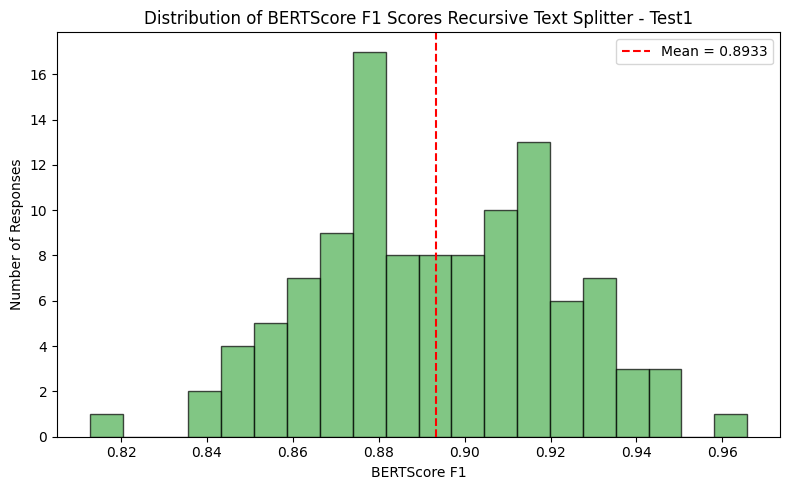

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.hist(
    non_idk_df["bertscore_f1"],
    bins=20,
    color="#4CAF50",
    edgecolor="black",
    alpha=0.7)

plt.axvline(
    non_idk_df["bertscore_f1"].mean(),
    linestyle="--",
    color="red",
    label=f"Mean = {non_idk_df['bertscore_f1'].mean():.4f}"
)


plt.xlabel("BERTScore F1")
plt.ylabel("Number of Responses")
plt.title(
    "Distribution of BERTScore F1 Scores "
    "Recursive Text Splitter - Test1"
)

plt.legend()
plt.tight_layout()

plt.savefig("../F1_dist_values_recursivesplit.pdf", dpi=300, bbox_inches='tight')

plt.show()


## **Evaluation using ERAG**

In [24]:
!pip install erag

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for erag: filename=erag-0.0.1-py3-none-any.whl size=7175 sha256=f4ec2a5f479aad5f36243315c2a136057a82c37b4267fe969e6d15bc6aa7c536
  Stored in directory: /root/.cache/pip/wheels/d6/97/00/1b262510f41a1cafeb3462fa3c2f7d87432bc342c9abd729c3
  Created wheel for pytrec_eval: filename=pytrec_eval-0.5-cp312-cp312-linux_x86_64.whl size=309356 sha256=6fe16b161643a58eb52bb6620175250da81ee9ed9f7aa2de9c0eacac22525bf8
  Stored in directory: /root/.cache/pip/wheels/c6/4a/9e/e17f9ea004e1c221bd0ff384732285211c4917b790d598ea51
Successfully built erag pytrec_eval


In [25]:
import os
import pandas as pd
from langchain_classic.chains import RetrievalQA
from erag import eval as erag_eval

In [26]:
def text_generator(queries_and_documents):
    results = dict()
    for question, documents in queries_and_documents.items():

        context = " ".join(documents)
        input_data = {"query": question, "docs": [{"page_content": context}]}

        generated_answer = qa_model.run(input_data)
        results[question] = generated_answer
    return results


In [27]:
def retrieve_documents(queries, num_retrieve=4):
    retrieved_documents = dict()
    for query in queries:
        docs = qdrant.similarity_search(query, k=num_retrieve)
        retrieved_documents[query] = [doc.page_content for doc in docs]
    return retrieved_documents


In [28]:
queries = [
        "What was the economic growth rate of Albania in 2003?",
        "What was the annual inflation rate by the end of November 2003?",
        "How did the monetary policy of the Bank of Albania affect interest rates in 2003?",
        "What factors contributed to the economy’s growth in 2003?",
        "How did the Albanian government manage its budget deficit in 2003?",
        "How much did Albania’s GDP grow in 2003?",
        "What was the inflation rate of Albania in December 2003?",
        "What was the REPO rate reduction in Albania as of May 2004?",
        "How did the appreciation of the domestic currency affect the economy in 2003?",
        "What significant change happened to the banking sector in 2003?",
        "What was one of the main risks identified for the Albanian banking system in 2017?",
        "What is the GDP growth forecast for Albania in 2017?",
        "What issue concerning inequality was raised in the Transition Report 2016-2017?",
        "How did the banking system's liquidity perform in 2017?",
        "What role does financial education play according to the Bank of Albania?",
        "What is the motto of Global Money Week?",
        "How many activities were organized during Global Money Week in 2017 in Albania?",
        "How many students participated in the Global Money Week events in 2017?",
        "What is the purpose of the financial education initiatives organized by the Bank of Albania?",
        "What collaborative effort supports financial education in Albania?",
        "What was Albania's economic growth rate in 2016?",
        "What was the inflation rate in Albania at the end of 2016?",
        "How did Albania’s public debt change in 2016?",
        "How did the accommodative monetary policy of the Bank of Albania impact lending in 2016?",
        "What two main obstacles did the Bank of Albania identify in the monetary policy pass-through mechanism?",
        "What was the Albanian economy’s growth rate in the second quarter of 2017?",
        "What factors contributed to Albania's economic recovery in 2017?",
        "What was the effect of Albania's monetary policy on the economy?",
        "How did non-performing loans in Albania change from 2014 to 2017?",
        "What role does the banking sector play in Albania's economic recovery?",
        "What financial indicator showed improvement in 2017 for Albanian enterprises?",
        "What is a significant challenge for the Albanian financial system according to the speech?",
        "What percentage of the Albanian population had a financial account in 2014?",
        "How did Albania compare to OECD countries in terms of financial inclusion in 2014?",
        "What is the role of the Albanian banking sector in addressing informality in the economy?",
        "What is the impact of remittances on the Albanian economy?",
        "What percentage of remittance transfers to Albania occurs through formal channels?",
        "Why do some Albanians abroad avoid using banking channels for remittances?",
        "What were the estimated costs of remittance transfers to Albania in 2016?",
        "How do remittances contribute to the balance of payments in Albania?",
        "How does the Bank of Albania plan to improve the efficiency of remittance flows?",
        "What is the Greenback project, and how does it relate to Albania?",
        "What is the primary use of remittances by Albanian households?",
        "What impact do remittances have on poverty in Albania?",
        "What action did the Bank of Albania commit to in relation to remittances?",
        "What was the purpose of the agreement between the Bank of Albania and SECO?",
        "How many activities were realized under the first phase of the SECO cooperation from 2013–2018?",
        "How did the Bank of Albania benefit from the cooperation with SECO?",
        "What role did SECO play in Albania’s monetary policy?",
        "How many staff members participated in SECO-related workshops during the first phase of the program?",
        "What academic opportunities did the SECO program offer to Bank of Albania employees?",
        "What impact did the SECO-funded forecasting models have on Albania's exchange rate management?",
        "How has SECO-supported research contributed to financial stability in Albania?",
        "What is the expected outcome of the second phase of SECO cooperation?",
        "What are the key priorities of the Bank of Albania under the SECO cooperation?",
        "What was the economic contraction of Albania during the second quarter of 2020 due to COVID-19?",
        "How many jobs were lost in Albania by the end of 2020?",
        "What was the inflation rate in Albania during the third quarter of 2020?",
        "How did the Bank of Albania respond to the COVID-19 economic crisis?",
        "How did the Albanian banking sector perform during the COVID-19 pandemic?",
        "What are the future challenges for Albania’s economy post-pandemic?",
        "What is the expected recovery period for the Albanian economy after COVID-19?",
        "What research areas dominated the 14th SEE Economic Research Workshop in 2020?",
        "What financial measures did the Bank of Albania take to stabilize the economy?",
        "What new topics are expected to gain attention in future workshops?",
        "How did the Bank of Albania respond to the COVID-19 pandemic in terms of monetary policy?",
        "What fiscal measures did the Albanian government implement during the COVID-19 pandemic?",
        "What regulatory measures did the Bank of Albania take to support borrowers during the pandemic?",
        "How did the Bank of Albania maintain financial stability during the COVID-19 crisis?",
        "What is the long-term policy outlook according to the Bank of Albania following the COVID-19 pandemic?",
        "What global economic challenge is highlighted as a long-term consequence of the pandemic?",
        "How has the COVID-19 pandemic accelerated changes in the financial sector?",
        "What role does fiscal policy play in managing the economic recovery post-COVID?",
        "What long-term challenge is associated with work-life balance due to the pandemic?",
        "How does the pandemic affect climate change discussions, according to the Bank of Albania?",
        "How did the COVID-19 pandemic affect GDP in the Western Balkans in 2020?",
        "What unconventional measures did central banks in the Western Balkans deploy during the pandemic?",
        "What fiscal measures did the Albanian government take to support businesses during the pandemic?",
        "How did the Bank of Albania support viable businesses facing temporary difficulties during the pandemic?",
        "What immediate regulatory action did the Bank of Albania take to strengthen the banking sector during the pandemic?",
        "How did the Rapid Financing Instrument (RFI) assist Albania during the pandemic?",
        "What impact did the Bank of Albania’s policies have on the banking sector during the pandemic?",
        "What key challenge is highlighted by the Bank of Albania regarding the post-pandemic recovery?",
        "What does the Bank of Albania emphasize as critical for long-term economic growth?",
        "What role does international cooperation play according to the Bank of Albania during the pandemic?",
        "What was the main cause of the financial crisis in Indonesia in 1997?",
        "How did Indonesia respond to the currency crisis in 1998?",
        "What was Indonesia's GDP growth rate in 1998?",
        "How did inflation in Indonesia behave during the worst point of the crisis?",
        "What was the role of Bank Indonesia in stabilizing inflation?",
        "How did Bank Indonesia address the trade finance arrears in 1998?",
        "What was the purpose of Indonesia’s Debt Restructuring Agency (INDRA)?",
        "How did the 1998 Jakarta Initiative contribute to economic recovery?",
        "How did the 1999 bank recapitalization program work in Indonesia?",
        "What was the expected role of the government in the Indonesian banking sector after the crisis?",
        "What was the main theme of the keynote speech by Agus D.W. Martowardojo at the International Seminar in Surabaya, 2016?",
        "What are the three sectors mentioned as pillars for fostering Islamic economic development?",
        "What percentage of global Islamic commercial finance is dominated by the Islamic banking sector?",
        "How did Islamic banking growth perform from 2008 to 2011 compared to 2011 to 2014?",
        "What was the global trend in Sukuk issuances between 2012 and 2015?",
        "How did the Islamic banking sector in Indonesia perform by July 2016?",
        "What potential does the Islamic social finance sector (zakat, awqaf) offer according to the speech?",
        "What is the role of zakat in poverty alleviation according to the keynote speech?",
        "What are the future goals of Bank Indonesia regarding Islamic finance as mentioned in the speech?",
        "What was the purpose of establishing the Zakat Core Principles?",
        "What was the theme of Bank Indonesia's 2020 annual meeting?",
        "How did the COVID-19 pandemic impact Indonesia’s economy in 2020?",
        "What fiscal stimulus did the Indonesian government provide during the COVID-19 pandemic?",
        "What was the projection for global economic growth in 2021 according to Bank Indonesia?",
        "What role did Bank Indonesia play in stabilizing the rupiah during the COVID-19 crisis?",
        "What was the impact of quantitative easing in emerging market economies during the pandemic?",
        "What were the key strategies for Indonesia’s economic recovery in 2021?",
        "How did Bank Indonesia support Micro, Small, and Medium Enterprises (MSMEs) during the pandemic?",
        "How did the COVID-19 pandemic affect Indonesia’s trade performance in 2020?",
        "What was the expected inflation rate in Indonesia for 2020?",
        "What was one of the major changes in the global financial system following the breakdown of the Bretton Woods system?",
        "What has been a primary objective of monetary policy in recent years?",
        "What are the two key functions of central banks discussed in this speech?",
        "How has financial liberalization affected banking sectors globally?",
        "What approach has evolved in central bank supervision concerning systemic stability?",
        "What has been the trend in the use of monetary policy instruments?",
        "How have technological advances impacted financial markets?",
        "What was one consequence of financial liberalization mentioned in the speech?",
        "What is one challenge central banks face due to more complete financial markets?",
        "What has been the impact of floating exchange rates on macroeconomic policies?",
        "What is one major responsibility of central banks discussed in the speech?",
        "What is a consequence of advances in information technology in financial markets?",
        "How did liberalization and innovation affect financial systems?",
        "What lesson can be drawn from recent financial crises according to the speaker?",
        "What was one of the macroeconomic challenges faced by East Asian countries during the financial crisis?",
        "What was the role of prudential regulation in financial crises?",
        "How does financial liberalization relate to capital market integration?",
        "What is the importance of exchange rate management during financial crises?",
        "What was one recommendation for handling banking system weaknesses?",
        "What was the speaker’s stance on official financing packages for resolving crises?",
        "What is the role of financial inclusion in economic development?",
        "What technological innovation is driving financial inclusion in remote areas?",
        "How has financial inclusion impacted global unbanked populations?",
        "What is the relationship between financial inclusion and financial stability?",
        "How does mobile money benefit local economies?",
        "What is a challenge faced by financial institutions in serving financially excluded populations?",
        "What impact does de-risking have on financial inclusion?",
        "Why is financial education important for new financial services users?",
        "What data-related challenge is highlighted in the speech?",
        "How can financial innovations positively impact the world’s financially excluded populations?",
        "What was the purpose of the SNB's COVID-19 refinancing facility (CRF)?",
        "How does the SARON differ from the previous Libor rate in the Swiss franc money market?",
        "Why are Swiss franc interest rates generally lower than those of other currencies?",
        "What role does the Swiss Money Market Value Chain play in Switzerland's financial infrastructure?",
        "What adjustments were made to the exemption thresholds in response to the coronavirus crisis?"
]


In [29]:
expected_outputs = {
    "What was the economic growth rate of Albania in 2003?": [
    "The economic growth rate was forecasted to be about 6 percent.",
    ],
    "What was the annual inflation rate by the end of November 2003?": [
    "The annual inflation rate by the end of November 2003 was 3.4 percent.",
    ],
    "How did the monetary policy of the Bank of Albania affect interest rates in 2003?": [
    "The Bank of Albania reduced interest rates three times, lowering the Repos rate by 1.5 percentage points." ,
    ],
    "What factors contributed to the economy’s growth in 2003?": [
    "Factors included stability in agricultural production, positive performance in services, industry, transport, increased trade volume, and remittances." ,
    ],
    "How did the Albanian government manage its budget deficit in 2003?": [
    "The budget deficit was financed through domestic borrowing, covering around 2.2 percent of GDP."
    ],
    "How much did Albania’s GDP grow in 2003?": [
    "Albania’s GDP grew by 6% in 2003."
    ],
    "What was the inflation rate of Albania in December 2003?": [
    "The inflation rate was 3.3% in December 2003."
    ],
    "What was the REPO rate reduction in Albania as of May 2004?": [
    "The REPO rate was reduced to 6%, which was the lowest ever."
    ],
    "How did the appreciation of the domestic currency affect the economy in 2003?": [
    "The appreciation of the domestic currency led to a reduction in borrowing costs and supported economic stability."
    ],
    "What significant change happened to the banking sector in 2003?": [
    "Two new banks of Albanian capital were established, and the Savings Bank was privatized by Raiffeisen Zentralbank."
    ],
    "What was one of the main risks identified for the Albanian banking system in 2017?": [
    "Non-performing loans were identified as the main risk."
    ],
    "What is the GDP growth forecast for Albania in 2017?": [
    "The economy was expected to grow faster, driven by domestic demand and improvement in foreign trading partners."
    ],
    "What issue concerning inequality was raised in the Transition Report 2016-2017?": [
    "The report highlighted deepening social inequality, particularly in terms of financial inclusion and opportunities."
    ],
    "How did the banking system's liquidity perform in 2017?": [
    "The banking system was liquid, well-capitalized, and able to withstand shocks from external factors."
    ],
    "What role does financial education play according to the Bank of Albania?": [
    "Financial education is considered crucial for addressing social inequality and enhancing financial inclusion."
    ],
    "What is the motto of Global Money Week?": [
    "The motto is 'Learn. Save. Earn."
    ],
    "How many activities were organized during Global Money Week in 2017 in Albania?": [
    "More than 45 activities were organized."
    ],
    "How many students participated in the Global Money Week events in 2017?": [
    "Over 3500 pupils and students participated."
    ],
    "What is the purpose of the financial education initiatives organized by the Bank of Albania?": [
    "The purpose is to raise awareness among young people about money, saving, and involvement in the financial system."
    ],
    "What collaborative effort supports financial education in Albania?": [
    "The Bank of Albania collaborates with the Ministry of Education and the Albanian Association of Banks to promote financial education."
    ],
    "What was Albania's economic growth rate in 2016?": [
    "Albania's economy grew by 3.5% in 2016."
    ],
    "What was the inflation rate in Albania at the end of 2016?": [
    "The inflation rate was 2.2% at the end of 2016."
    ],
    "How did Albania’s public debt change in 2016?": [
    "Public debt decreased from 72.7% of GDP in 2015 to 71% in 2016."
    ],
    "How did the accommodative monetary policy of the Bank of Albania impact lending in 2016?": [
    'It contributed to an increase in credit to the private sector, particularly in Albanian lek.'
    ],
    'What two main obstacles did the Bank of Albania identify in the monetary policy pass-through mechanism?': [
    'The two obstacles were the high level of non-performing loans and the high level of euroisation in the economy.'
    ],
    'What was the Albanian economy’s growth rate in the second quarter of 2017?': [
    'The Albanian economy grew by 4.1% in the second quarter of 2017.'
    ],
    "What factors contributed to Albania's economic recovery in 2017?": [
    'The recovery was driven by private domestic demand, improved international trade balance, increased public spending, and high foreign direct investments.'
    ],
    "What was the effect of Albania's monetary policy on the economy?": [
    'The accommodative monetary policy guaranteed low interest rates and ample liquidity, supporting domestic demand.'
    ],
    'How did non-performing loans in Albania change from 2014 to 2017?': [
    'The ratio of non-performing loans decreased by 10 percentage points from its peak in 2014.'
    ],
    "What role does the banking sector play in Albania's economic recovery?": [
    'The banking sector plays a key role in supporting economic recovery, particularly through lending.'
    ],
    'What financial indicator showed improvement in 2017 for Albanian enterprises?': [
    'Survey results indicated an improved financial situation for enterprises in 2017.'
    ],
    'What is a significant challenge for the Albanian financial system according to the speech?': [
    'The underdeveloped financial system creates challenges for the effectiveness of monetary policy and financial stability.'
    ],
    'What percentage of the Albanian population had a financial account in 2014?': [
    'Only 38% of the Albanian population had a financial account in 2014.'
    ],
    'How did Albania compare to OECD countries in terms of financial inclusion in 2014?': [
    'In 2014, 92% of the population in OECD countries had a financial account, compared to 38% in Albania.'
    ],
    'What is the role of the Albanian banking sector in addressing informality in the economy?': [
    'The banking sector plays a critical role in using certified information to combat informality and enhance financial stability.'
    ],
    'What is the impact of remittances on the Albanian economy?': [
    'Remittances are a substantial source of financing for economic growth and represent a vital contribution to the welfare of Albanian households.'
    ],
    'What percentage of remittance transfers to Albania occurs through formal channels?': [
    'The majority of remittances are transferred through formal channels, such as money transfer financial institutions.'
    ],
    'Why do some Albanians abroad avoid using banking channels for remittances?': [
    'The high costs of money transfers and perceived complex procedures are reasons for avoiding banking channels.'
    ],
    'What were the estimated costs of remittance transfers to Albania in 2016?': [
    'The costs of remittance transfers to Albania were estimated at 9.4% of the amount sent.'
    ],
    'How do remittances contribute to the balance of payments in Albania?': [
    'Remittances contribute significantly to Albania’s balance of payments, providing an important source of income.'
    ],
    'How does the Bank of Albania plan to improve the efficiency of remittance flows?': [
    'The Bank of Albania is working with the World Bank on projects to reduce transfer costs and enhance financial inclusion.'
    ],
    'What is the Greenback project, and how does it relate to Albania?': [
    'The Greenback project is a World Bank initiative aimed at improving the efficiency of remittances in receiving countries, including Albania.'
    ],
    'What is the primary use of remittances by Albanian households?': [
    'Remittances are primarily used for consumption, medication, education, and investment in residential properties.'
    ],
    'What impact do remittances have on poverty in Albania?': [
    'Remittances help reduce poverty and improve the quality of life for recipient households.'
    ],
    'What action did the Bank of Albania commit to in relation to remittances?': [
    'The Bank of Albania committed to publishing a dedicated report on remittances every June, coinciding with the International Day of Family Remittances.'
    ],
    'What was the purpose of the agreement between the Bank of Albania and SECO?': [
    'The agreement aimed to provide technical assistance to the Bank of Albania, focusing on improving analysis and decision-making processes.'
    ],
    'How many activities were realized under the first phase of the SECO cooperation from 2013–2018?': [
    'There were 30 different activities realized under the first phase of cooperation.'
    ],
    'How did the Bank of Albania benefit from the cooperation with SECO?': [
    'The Bank of Albania improved its forecasting and analysis models, enhancing its decision-making and policy formulation capabilities.'
    ],
    'What role did SECO play in Albania’s monetary policy?': [
    'SECO-funded projects helped Albania adopt contemporary models for evaluating foreign currency reserves and managing liquidity in the banking sector.'
    ],
    'How many staff members participated in SECO-related workshops during the first phase of the program?': [
    'Around 270 employees participated in 18 workshops during the first phase of the program.'
    ],
    'What academic opportunities did the SECO program offer to Bank of Albania employees?': [
    'Three employees attended post-university studies at The Graduate Institute Geneva.'
    ],
     "What impact did the SECO-funded forecasting models have on Albania's exchange rate management?": [
     "The models helped manage appreciation pressures on the exchange rate effectively."
    ],
    "How has SECO-supported research contributed to financial stability in Albania?": [
        "The research helped develop regulations that accelerated the reduction of non-performing loans and created a safer regulatory environment."
    ],
    "What is the expected outcome of the second phase of SECO cooperation?": [
        "The second phase aims to improve monetary policy decision-making and macro-prudential policy formulation."
    ],
    "What are the key priorities of the Bank of Albania under the SECO cooperation?": [
        "Key priorities include enhancing research results\u2019 impact on decision-making and adopting rigorous research standards."
    ],
    "What was the economic contraction of Albania during the second quarter of 2020 due to COVID-19?": [
        "The Albanian economy contracted by -10.2% during the second quarter of 2020."
    ],
    "How many jobs were lost in Albania by the end of 2020?": [
        "Around 50,000 jobs were lost, leading to an unemployment rate of 11.9%."
    ],
    "What was the inflation rate in Albania during the third quarter of 2020?": [
        "The inflation rate decreased to 1.4% in the third quarter."
    ],
    "How did the Bank of Albania respond to the COVID-19 economic crisis?": [
        "The Bank provided monetary stimulus, lowered interest rates, injected liquidity, and supported financial intermediation."
    ],
    "How did the Albanian banking sector perform during the COVID-19 pandemic?": [
        "The banking sector remained sound, with adequate capital and growing credit to the economy."
    ],
    "What are the future challenges for Albania\u2019s economy post-pandemic?": [
        "The main challenges include potential long-term damage to productive capacities and structural changes in economic behavior."
    ],
    "What is the expected recovery period for the Albanian economy after COVID-19?": [
        "Economic activity is expected to revitalize over the next two years."
    ],
    "What research areas dominated the 14th SEE Economic Research Workshop in 2020?": [
        "Research on monetary policy, financial stability, and the impact of COVID-19 dominated the workshop."
    ],
    "What financial measures did the Bank of Albania take to stabilize the economy?": [
        "The Bank provided liquidity, ensured credit flow, and kept interest rates low to stabilize the economy."
    ],
    "What new topics are expected to gain attention in future workshops?": [
        "Topics like climate change, financial inclusion, and Central Bank Digital Currencies are expected to gain attention."
    ],
    "How did the Bank of Albania respond to the COVID-19 pandemic in terms of monetary policy?": [
        "The Bank of Albania reduced the policy rate to 0.5% and injected liquidity into the system to support financial intermediation and reduce debt servicing costs."
    ],
    "What fiscal measures did the Albanian government implement during the COVID-19 pandemic?": [
        "The government increased social transfers, supported the health sector, offered temporary tax relief, and introduced sovereign credit guarantee schemes."
    ],
    "What regulatory measures did the Bank of Albania take to support borrowers during the pandemic?": [
        "The Bank applied temporary regulatory relief to encourage deferrals of loan installments and the consensual restructuring of loans."
    ],
    "How did the Bank of Albania maintain financial stability during the COVID-19 crisis?": [
        "The Bank took both macro and micro prudential measures to strengthen banks' balance sheets and preserve lending capacity."
    ],
    "What is the long-term policy outlook according to the Bank of Albania following the COVID-19 pandemic?": [
        "The Bank believes that the policy stance should remain accommodative and data-dependent, with any policy normalization being carefully coordinated."
    ],
    "What global economic challenge is highlighted as a long-term consequence of the pandemic?": [
        "The pandemic may widen the gap in inequality both among advanced and developing economies and within individual economies."
    ],
    "How has the COVID-19 pandemic accelerated changes in the financial sector?": [
        "The pandemic has accelerated the shift toward digital finance and digital business, which may significantly change the financial industry landscape."
    ],
    "What role does fiscal policy play in managing the economic recovery post-COVID?": [
        "Fiscal policy should remain supportive, providing necessary financial space to sustain recovery, while maintaining market credibility and the sustainability of public finances."
    ],
    "What long-term challenge is associated with work-life balance due to the pandemic?": [
        "Remote working, which became more prevalent during the pandemic, may become a permanent option for many global companies."
    ],
    "How does the pandemic affect climate change discussions, according to the Bank of Albania?": [
        "The lockdown may trigger new momentum toward a cleaner economy, though the long-term effects on climate change remain uncertain."
    ],
    "How did the COVID-19 pandemic affect GDP in the Western Balkans in 2020?": [
        "The GDP drop in the Western Balkans ranged from -3.1% (World Bank) to -5.2% (IMF)."
    ],
    "What unconventional measures did central banks in the Western Balkans deploy during the pandemic?": [
        "Central banks deployed unconventional measures such as QE-type operations, long-term liquidity injections, and credit support schemes."
    ],
    "What fiscal measures did the Albanian government take to support businesses during the pandemic?": [
        "The Albanian government provided tax relief, direct transfers, and sovereign credit guarantee schemes."
    ],
    "How did the Bank of Albania support viable businesses facing temporary difficulties during the pandemic?": [
        "The Bank instructed banks to offer liquidity relief in the form of a short-term moratorium on credit installments and targeted credit restructuring."
    ],
    "What immediate regulatory action did the Bank of Albania take to strengthen the banking sector during the pandemic?": [
        "The Bank abolished dividend payments across the banking sector to strengthen its capital base."
    ],
    "How did the Rapid Financing Instrument (RFI) assist Albania during the pandemic?": [
        "The RFI facilitated Albania's fiscal stimulus and helped stabilize domestic financial markets by signaling the country's ability to access various funding sources."
    ],
    "What impact did the Bank of Albania\u2019s policies have on the banking sector during the pandemic?": [
        "The policies ensured that the Albanian banking sector remained solid, solvent, and liquid, with stable interest rates and continued access to credit."
    ],
    "What key challenge is highlighted by the Bank of Albania regarding the post-pandemic recovery?": [
        "A key challenge is ensuring the cyclical recovery of economies while accounting for the structural changes the crisis has left behind."
    ],
    "What does the Bank of Albania emphasize as critical for long-term economic growth?": [
        "Sound monetary and financial fundamentals, constructed through careful policies and structural reforms during good times, are critical for long-term sustainable growth."
    ],
    "What role does international cooperation play according to the Bank of Albania during the pandemic?": [
        "International cooperation in the form of financial assistance and policy guidance is crucial for alleviating costs to emerging economies and avoiding negative spillovers."
    ],
    "What was the main cause of the financial crisis in Indonesia in 1997?": [
        "The crisis was triggered by the sharp depreciation of the rupiah, losing about 85% of its value from pre-crisis levels."
    ],
    "How did Indonesia respond to the currency crisis in 1998?": [
        "Indonesia implemented strict monetary policies, supported by the IMF and international institutions, to stabilize the rupiah."
    ],
    "What was Indonesia's GDP growth rate in 1998?": [
        "Indonesia\u2019s GDP contracted by about 14% in 1998."
    ],
    "How did inflation in Indonesia behave during the worst point of the crisis?": [
        "Indonesia\u2019s inflation rate surged dramatically, reaching almost 13% in one month alone in early 1998."
    ],
    "What was the role of Bank Indonesia in stabilizing inflation?": [
        "Bank Indonesia adopted tight monetary policies and improved transparency, announcing crucial monetary aggregate data weekly."
    ],
    "How did Bank Indonesia address the trade finance arrears in 1998?": [
        "Bank Indonesia cleared trade finance arrears to restore confidence in Indonesia\u2019s access to trade financing."
    ],
    "What was the purpose of Indonesia\u2019s Debt Restructuring Agency (INDRA)?": [
        "INDRA provided foreign exchange protection to borrowers renegotiating their debts, improving their creditworthiness."
    ],
    "How did the 1998 Jakarta Initiative contribute to economic recovery?": [
        "The Jakarta Initiative aimed to facilitate debtor/creditor negotiations and provided the right framework for restructuring."
    ],
    "How did the 1999 bank recapitalization program work in Indonesia?": [
        "The program classified banks into three categories based on capital adequacy, with non-viable banks liquidated and viable ones recapitalized by the government."
    ],
    "What was the expected role of the government in the Indonesian banking sector after the crisis?": [
        "The government\u2019s involvement was temporary, aiming to divest its share in private banks within three to five years and restore them to private ownership."
    ],
    "What was the main theme of the keynote speech by Agus D.W. Martowardojo at the International Seminar in Surabaya, 2016?": [
        "The theme was 'Integrating Islamic Commercial and Social Finance to Strengthen Financial System Stability.'"
    ],
    "What are the three sectors mentioned as pillars for fostering Islamic economic development?": [
        "The three sectors are Islamic banking, Islamic capital markets, and takaful."
    ],
    "What percentage of global Islamic commercial finance is dominated by the Islamic banking sector?": [
        "The Islamic banking sector dominates 80% of the global Islamic commercial finance system."
    ],
    "How did Islamic banking growth perform from 2008 to 2011 compared to 2011 to 2014?": [
        "Islamic banking grew by 17.1% from 2008 to 2011 but moderated to 13.8% from 2011 to 2014."
    ],
    "What was the global trend in Sukuk issuances between 2012 and 2015?": [
        "Global Sukuk issuances peaked in 2012 and 2013 but slowed down in 2014 and 2015, with a 43% drop in 2015 to about USD 60 billion."
    ],
    "How did the Islamic banking sector in Indonesia perform by July 2016?": [
        "Islamic banking in Indonesia rebounded with 12.0% growth year-over-year by July 2016."
    ],
    "What potential does the Islamic social finance sector (zakat, awqaf) offer according to the speech?": [
        "The Islamic social finance sector offers significant potential, especially for addressing poverty and socio-economic well-being."
    ],
    "What is the role of zakat in poverty alleviation according to the keynote speech?": [
        "Zakat enables the poor to fulfill basic needs and can empower them by providing funds for those with little access to formal financing."
    ],
    "What are the future goals of Bank Indonesia regarding Islamic finance as mentioned in the speech?": [
        "Bank Indonesia aims to make Indonesia a regional Islamic finance center by enhancing zakat and awqaf systems and promoting inclusive finance."
    ],
    "What was the purpose of establishing the Zakat Core Principles?": [
        "The Zakat Core Principles were established to serve as a main reference for the elaboration of zakat regulations, improving the regulatory framework for zakat management."
    ],
    "What was the theme of Bank Indonesia's 2020 annual meeting?": [
        "The theme was 'Synergize to Build Optimism for Economic Recovery.'"
    ],
    "How did the COVID-19 pandemic impact Indonesia\u2019s economy in 2020?": [
        "The pandemic caused a significant economic recession, with decreased human mobility and reduced economic activity, particularly in the second quarter of 2020."
    ],
    "What fiscal stimulus did the Indonesian government provide during the COVID-19 pandemic?": [
        "The government allocated Rp. 695.2 trillion for health, social assistance, and business incentives to support economic recovery."
    ],
    "What was the projection for global economic growth in 2021 according to Bank Indonesia?": [
        "The global economy was projected to grow by 5.0% in 2021 after contracting by 3.8% in 2020."
    ],
    "What role did Bank Indonesia play in stabilizing the rupiah during the COVID-19 crisis?": [
        "Bank Indonesia intervened in the spot market and conducted quantitative easing, reducing the policy rate to a historic low of 3.75%."
    ],
    "What was the impact of quantitative easing in emerging market economies during the pandemic?": [
        "Quantitative easing supported the financial markets, with Bank Indonesia injecting liquidity into the banking sector to stabilize the economy."
    ],
    "What were the key strategies for Indonesia\u2019s economic recovery in 2021?": [
        "Key strategies included improving human resources, infrastructure development, and fostering a better business climate through regulatory reforms."
    ],
    "How did Bank Indonesia support Micro, Small, and Medium Enterprises (MSMEs) during the pandemic?": [
        "The government and Bank Indonesia provided financial incentives and tax relief to MSMEs as part of the recovery plan."
    ],
    "How did the COVID-19 pandemic affect Indonesia\u2019s trade performance in 2020?": [
        "The pandemic caused disruptions in global supply chains, leading to a reduction in trade volumes, but exports gradually recovered, particularly to the US and China."
    ],
    "What was the expected inflation rate in Indonesia for 2020?": [
        "Inflation was expected to be lower than 2% by the end of 2020 due to weak domestic demand and adequate supply."
    ],
    "What was one of the major changes in the global financial system following the breakdown of the Bretton Woods system?": [
        "The move to floating exchange rates in the early 1970s, followed by a period of high inflation and disappointing growth."
    ],
    "What has been a primary objective of monetary policy in recent years?": [
        "The primary objective has become price stability, as exploiting the Phillips curve trade-off led to negative outcomes."
    ],
    "What are the two key functions of central banks discussed in this speech?": [
        "Preserving monetary stability and maintaining financial system stability."
    ],
    "How has financial liberalization affected banking sectors globally?": [
        "It has led to banking sector difficulties and a shift towards emphasizing capital adequacy."
    ],
    "What approach has evolved in central bank supervision concerning systemic stability?": [
        "Central banks now focus more on capital adequacy rather than activity regulation, with some countries rethinking supervisory structures."
    ],
    "What has been the trend in the use of monetary policy instruments?": [
        "Market management techniques, such as repurchase operations, have become the standard for controlling short-term interest rates."
    ],
    "How have technological advances impacted financial markets?": [
        "Technological advances have increased the scope for arbitrage and globalized financial markets, creating new systemic risks."
    ],
    "What was one consequence of financial liberalization mentioned in the speech?": [
        "The emergence of more integrated global capital markets and a quantum increase in financial intermediation."
    ],
    "What is one challenge central banks face due to more complete financial markets?": [
        "The difficulty in using direct controls to achieve policy objectives as markets become more capable of arbitraging around restrictions."
    ],
    "What has been the impact of floating exchange rates on macroeconomic policies?": [
        "Policies must now be credible to markets, as bad policies are quickly disciplined by market reactions."
    ],
    "What is one major responsibility of central banks discussed in the speech?": [
        "Preserving financial stability, especially given the increased capacity for financial disturbances to spill over into the real economy."
    ],
    "What is a consequence of advances in information technology in financial markets?": [
        "Lower transaction costs, expanded trading opportunities, and stronger linkages between markets."
    ],
    "How did liberalization and innovation affect financial systems?": [
        "They made national financial systems more vulnerable to both domestically-generated stresses and internationally-transmitted disturbances."
    ],
    "What lesson can be drawn from recent financial crises according to the speaker?": [
        "Economies with strong fundamentals can still fall victim to sudden loss of confidence, particularly due to rigid exchange rate regimes."
    ],
    "What was one of the macroeconomic challenges faced by East Asian countries during the financial crisis?": [
        "Capital inflows contributed to inflationary pressures, leading to balance of payments deficits and currency crises."
    ],
    "What was the role of prudential regulation in financial crises?": [
        "Weak prudential regulation contributed to financial system vulnerabilities, highlighting the need for stronger regulatory frameworks."
    ],
    "How does financial liberalization relate to capital market integration?": [
        "Liberalization increased the integration of emerging markets into international capital markets, leading to both benefits and risks."
    ],
    "What is the importance of exchange rate management during financial crises?": [
        "Exchange rate regimes must be adaptable to changing conditions to avoid imbalances that can lead to abrupt adjustments."
    ],
    "What was one recommendation for handling banking system weaknesses?": [
        "The implementation of the Basle Committee\u2019s Core Principles for banking supervision to strengthen financial systems."
    ],
    "What was the speaker\u2019s stance on official financing packages for resolving crises?": [
        "Larger official financing packages are not the answer; instead, private sector involvement is necessary to prevent moral hazard."
    ],
    "What is the role of financial inclusion in economic development?": [
        "Financial inclusion fosters equitable growth, poverty reduction, gender equality, and food security."
    ],
    "What technological innovation is driving financial inclusion in remote areas?": [
        "Mobile phones are enabling access to financial services in remote regions, with significant uptake in countries like Kenya and Tanzania."
    ],
    "How has financial inclusion impacted global unbanked populations?": [
        "Since 2011, 700 million adults gained access to financial services, reducing the unbanked population by 20%."
    ],
    "What is the relationship between financial inclusion and financial stability?": [
        "Greater financial inclusion can enhance financial stability, particularly in countries with strong supervision."
    ],
    "How does mobile money benefit local economies?": [
        "Mobile money supports economic growth by allowing faster, cheaper, and safer domestic remittances."
    ],
    "What is a challenge faced by financial institutions in serving financially excluded populations?": [
        "Traditional business models are not well-suited for small-scale savings, payments, and lending services that excluded households need."
    ],
    "What impact does de-risking have on financial inclusion?": [
        "De-risking, where banks cease high-risk business lines, can increase financial exclusion and raise risks of money-laundering."
    ],
    "Why is financial education important for new financial services users?": [
        "Many financially excluded individuals may lack the knowledge to make informed decisions about financial products, posing consumer protection challenges."
    ],
    "What data-related challenge is highlighted in the speech?": [
        "There is a need for more and better data to understand financial exclusion and adopt appropriate policies."
    ],
    "How can financial innovations positively impact the world\u2019s financially excluded populations?": [
        "Financial innovations, if properly managed, can bring tremendous positive changes to financially excluded populations, enhancing their access to services."
    ],
    "What was the purpose of the SNB's COVID-19 refinancing facility (CRF)?": [
    "The CRF was set up to ensure continued credit and liquidity supply to small and medium-sized enterprises, supported by Swiss federal government loan guarantees."
    ],
    "How does the SARON differ from the previous Libor rate in the Swiss franc money market?": [
    "SARON is a secured overnight rate based on actual transactions and binding quotes, unlike the Libor, which was an unsecured three-month rate."
    ],
    "Why are Swiss franc interest rates generally lower than those of other currencies?": [
    "Swiss franc interest rates are lower due to low inflation in Switzerland and the franc's status as a safe-haven currency."
    ],
    "What role does the Swiss Money Market Value Chain play in Switzerland's financial infrastructure?": [
    "The Swiss Money Market Value Chain ensures seamless trading, settlement, and liquidity redistribution, fostering trust and transparency in the market."
    ],
    "What adjustments were made to the exemption thresholds in response to the coronavirus crisis?": [
    "In April 2020, the exemption thresholds were raised by 20% to reduce the burden on the banking system and increase lending capacity during the crisis."
    ],
}



In [30]:
from bert_score import score

def bertscore_metric(generated_outputs, expected_outputs, lang="en"):

    results = {}
    for query, gen_output in generated_outputs.items():
        exp_outputs_query = expected_outputs[query]
        if not isinstance(exp_outputs_query, list):
            exp_outputs_query = [exp_outputs_query]


        P, R, F1 = score(
            [gen_output] * len(exp_outputs_query),  # candidate
            exp_outputs_query,                      # reference
            lang=lang,
            verbose=False
        )


        best_f1 = F1.max().item()
        results[query] = best_f1
    return results


In [32]:
#Using bertscore_metric as similarity metric for Erag

retrieved_documents = retrieve_documents(queries, num_retrieve=4)

retrieval_metrics = {'P_4', 'success'}


results = erag_eval(
    retrieval_results=retrieved_documents,
    expected_outputs=expected_outputs,
    text_generator=text_generator,
    downstream_metric=bertscore_metric,
    retrieval_metrics=retrieval_metrics
)

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
print("eRAG Evaluation Results:")
print(results)

eRAG Evaluation Results:
{'per_input': {'What was the economic growth rate of Albania in 2003?': {'P_4': 0.8861236423254013, 'success': 0.898676872253418}, 'What was the annual inflation rate by the end of November 2003?': {'P_4': 0.9010515809059143, 'success': 0.9032444953918457}, 'How did the monetary policy of the Bank of Albania affect interest rates in 2003?': {'P_4': 0.9045218080282211, 'success': 0.907672107219696}, 'What factors contributed to the economy’s growth in 2003?': {'P_4': 0.8553098291158676, 'success': 0.8636130690574646}, 'How did the Albanian government manage its budget deficit in 2003?': {'P_4': 0.8877790123224258, 'success': 0.8928743600845337}, 'How much did Albania’s GDP grow in 2003?': {'P_4': 0.9349649250507355, 'success': 0.9441378116607666}, 'What was the inflation rate of Albania in December 2003?': {'P_4': 0.9317808598279953, 'success': 0.9600452780723572}, 'What was the REPO rate reduction in Albania as of May 2004?': {'P_4': 0.9186901748180389, 'succes

In [34]:
#extracting Precision_4 and Success values for test1(Recursive Splitter)
precision_4_values = [item['P_4'] for item in results['per_input'].values()]
success_values = [item['success'] for item in results['per_input'].values()]

print("Precision values for recursive text splitter(test1) :", precision_4_values)
print("Success values for recursive text splitter(test1) :", success_values)


Precision values for recursive text splitter(test1) : [0.8861236423254013, 0.9010515809059143, 0.9045218080282211, 0.8553098291158676, 0.8877790123224258, 0.9349649250507355, 0.9317808598279953, 0.9186901748180389, 0.8838178217411041, 0.8482339084148407, 0.9103514701128006, 0.8497681468725204, 0.8996276557445526, 0.8691358268260956, 0.9058401882648468, 0.8904359638690948, 0.9144821614027023, 0.8548198640346527, 0.9056674838066101, 0.9261389821767807, 0.87680684030056, 0.8737653642892838, 0.9657758474349976, 0.8945792019367218, 0.8740518391132355, 0.9016381055116653, 0.8420421183109283, 0.8611271381378174, 0.8841273635625839, 0.9041266441345215, 0.876329705119133, 0.9180700778961182, 0.8682005405426025, 0.8890399485826492, 0.9143249839544296, 0.9024302959442139, 0.8734394162893295, 0.9370200783014297, 0.8801852166652679, 0.9221373647451401, 0.9068622589111328, 0.9260476380586624, 0.8839376419782639, 0.9111567288637161, 0.9334547519683838, 0.9176212549209595, 0.8769394010305405, 0.866042

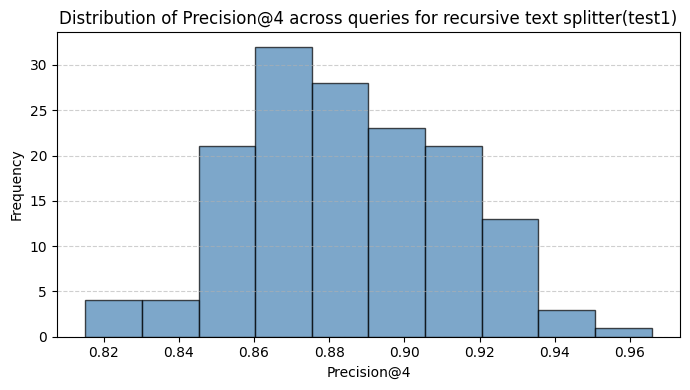

In [35]:
import matplotlib.pyplot as plt
import pandas as pd


rows = []
for q, vals in results["per_input"].items():
    rows.append({"query": q, "Precision_4": vals["P_4"]})
df_erag = pd.DataFrame(rows)



plt.figure(figsize=(7,4))
plt.hist(df_erag["Precision_4"], bins=10, color="steelblue", edgecolor="black", alpha=0.7)
plt.xlabel("Precision@4")
plt.ylabel("Frequency")
plt.title("Distribution of Precision@4 across queries for recursive text splitter(test1)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("../Precision4_recursivesplit.pdf", dpi=300, bbox_inches='tight')

plt.show()


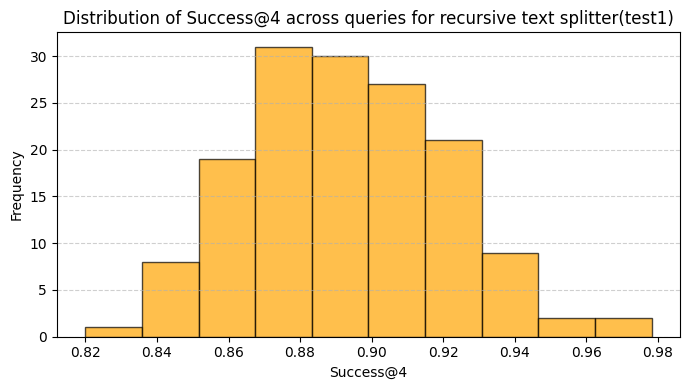

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

rows = []
for q, vals in results["per_input"].items():
    rows.append({"query": q, "Success_4": vals["success"]})
df_erag = pd.DataFrame(rows)


plt.figure(figsize=(7,4))
plt.hist(df_erag["Success_4"], bins=10, color="orange", edgecolor="black", alpha=0.7)
plt.xlabel("Success@4")
plt.ylabel("Frequency")
plt.title("Distribution of Success@4 across queries for recursive text splitter(test1)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("../Success4_recursivesplit.pdf", dpi=300, bbox_inches='tight')

plt.show()
